# 🧠 Brain Tumor Dataset — Balance First, Then Augment ×2
### Pipeline:
### Original (imbalanced) → Step 1: Balance → Step 2: Augment ×2 → Train

## Step 1 — Import Libraries

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print('✅ Libraries imported!')
print('TensorFlow version:', tf.__version__)

✅ Libraries imported!
TensorFlow version: 2.20.0


## Step 2 — Set Paths & Config

In [ ]:
# ── Original dataset paths ─────────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/Brain_tumor/Datasplit_v2'
train_dir = os.path.join(BASE_DIR, 'train')
valid_dir = os.path.join(BASE_DIR, 'valid')
test_dir  = os.path.join(BASE_DIR, 'test')

# ── Output folders (writable) ─────────────────────────────────────
balanced_dir  = '/content/drive/MyDrive/Brain_tumor/Step1_Balanced'    # after balancing
augmented_dir = '/content/drive/MyDrive/Brain_tumor/Step2_Augmented'   # after augmenting x2

# ── Config ────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 64
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print('✅ Paths configured!')
print(f'  Original train : {train_dir}')
print(f'  After balance  : {balanced_dir}')
print(f'  After augment  : {augmented_dir}')

✅ Paths configured!
  Original train : /content/drive/MyDrive/Brain_tumor/Datasplit_v2/train
  After balance  : /content/drive/MyDrive/Brain_tumor/Step1_Balanced
  After augment  : /content/drive/MyDrive/Brain_tumor/Step2_Augmented


## Step 3 — Check Original Class Distribution

In [ ]:
def count_images(directory):
    """Count images per class subfolder and return a dict."""
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(imgs)
    return counts


original_counts = count_images(train_dir)

print('📊 ORIGINAL Dataset Distribution:')
print('=' * 45)
for cls, n in original_counts.items():
    bar = '█' * (n // 50)
    print(f'  {cls:15s}: {n:5d}  {bar}')
print(f'\n  Total   : {sum(original_counts.values())}')
print(f'  Max     : {max(original_counts.values())}')
print(f'  Min     : {min(original_counts.values())}')
print(f'  Ratio   : {max(original_counts.values())/min(original_counts.values()):.2f}x imbalance')

📊 ORIGINAL Dataset Distribution:
  glioma         :  2627  ████████████████████████████████████████████████████
  meningioma     :  3040  ████████████████████████████████████████████████████████████
  no_tumor       :  2629  ████████████████████████████████████████████████████
  pituitary      :  3294  █████████████████████████████████████████████████████████████████

  Total   : 11590
  Max     : 3294
  Min     : 2627
  Ratio   : 1.25x imbalance


## Step 4 — Visualise Original Distribution

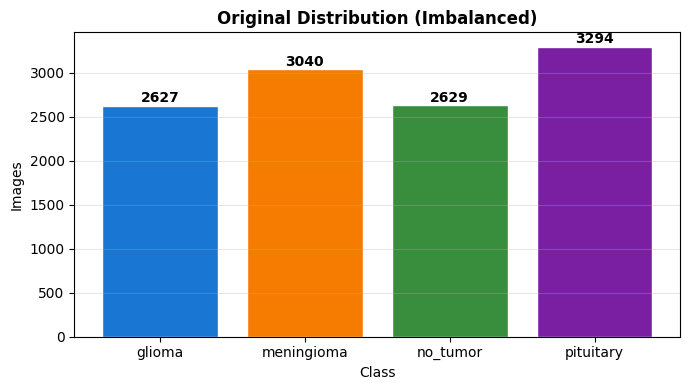

In [ ]:
def plot_distribution(counts_dict, title, color_alpha=1.0, ax=None):
    colors = ['#1976D2', '#F57C00', '#388E3C', '#7B1FA2']
    classes = list(counts_dict.keys())
    values  = list(counts_dict.values())
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(classes, values, color=colors, edgecolor='white', alpha=color_alpha)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Images')
    ax.grid(True, alpha=0.3, axis='y')
    return ax

plot_distribution(original_counts, 'Original Distribution (Imbalanced)')
plt.tight_layout()
plt.show()

---
# 🔵 STAGE 1 — Balance the Dataset
**Goal:** Make every class have the same number of images as the largest class.

- All original images are copied as-is
- Minority classes get augmented copies added until they reach `target_count`
- No original image is deleted

## Step 5 — Define Balance Function

In [ ]:
def balance_dataset(src_dir, dst_dir, img_size=(224, 224), seed=42):
    """
    STAGE 1: Balance dataset.
    - Copies all original images
    - Augments minority classes to match the largest class count

    Augmentation used here is MILD (just enough to fill the gap):
      rotation ±15°, shear 0.2, zoom 0.2, h-flip, brightness 0.8-1.2
    """
    random.seed(seed)
    np.random.seed(seed)

    # Mild augmentation just for filling the minority gap
    aug = ImageDataGenerator(
        rotation_range=15,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )

    classes = sorted([d for d in os.listdir(src_dir)
                      if os.path.isdir(os.path.join(src_dir, d))])

    # Count originals
    counts = {}
    for cls in classes:
        imgs = [f for f in os.listdir(os.path.join(src_dir, cls))
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        counts[cls] = len(imgs)

    target_count = max(counts.values())

    print(f'\n🔵 STAGE 1 — Balancing Dataset')
    print(f'   Target per class : {target_count}')
    print('=' * 55)

    # Clear and recreate destination
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)

    for cls in classes:
        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)

        imgs = [f for f in os.listdir(src_cls)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Copy ALL originals
        for fname in imgs:
            shutil.copy(os.path.join(src_cls, fname),
                        os.path.join(dst_cls, fname))

        # Augment minority classes
        needed    = target_count - len(imgs)
        aug_count = 0
        while aug_count < needed:
            fname = random.choice(imgs)
            img   = load_img(os.path.join(src_cls, fname), target_size=img_size)
            x     = np.expand_dims(img_to_array(img), 0)
            for batch in aug.flow(x, batch_size=1):
                tf.keras.utils.save_img(
                    os.path.join(dst_cls, f'bal_{aug_count}_{fname}'), batch[0])
                aug_count += 1
                break

        final = len(os.listdir(dst_cls))
        tag   = '  (majority — copied only)' if needed == 0 else f'  (+{needed} aug to fill gap)'
        print(f'  {cls:15s}: {counts[cls]:4d} → {final:4d}{tag}')

    print('\n  ✅ Stage 1 complete — dataset balanced!')
    return target_count


print('✅ balance_dataset() defined!')

✅ balance_dataset() defined!


## Step 6 — Run Balancing

In [ ]:
balanced_target = balance_dataset(
    src_dir  = train_dir,
    dst_dir  = balanced_dir,
    img_size = IMG_SIZE,
    seed     = SEED
)


🔵 STAGE 1 — Balancing Dataset
   Target per class : 3294
  glioma         : 2627 → 3294  (+667 aug to fill gap)
  meningioma     : 3040 → 3294  (+254 aug to fill gap)
  no_tumor       : 2629 → 3294  (+665 aug to fill gap)
  pituitary      : 3294 → 3294  (majority — copied only)

  ✅ Stage 1 complete — dataset balanced!


## Step 7 — Verify Balanced Dataset

In [ ]:
balanced_counts = count_images(balanced_dir)

print('📊 After STAGE 1 — Balanced:')
print('=' * 45)
for cls, n in balanced_counts.items():
    bar = '█' * (n // 50)
    print(f'  {cls:15s}: {n:5d}  {bar}')
print(f'\n  Total : {sum(balanced_counts.values())}')

assert len(set(balanced_counts.values())) == 1, '⚠️ Classes not equal!'
print('  ✅ All classes equal!')

📊 After STAGE 1 — Balanced:
  glioma         :  3294  █████████████████████████████████████████████████████████████████
  meningioma     :  3294  █████████████████████████████████████████████████████████████████
  no_tumor       :  3294  █████████████████████████████████████████████████████████████████
  pituitary      :  3294  █████████████████████████████████████████████████████████████████

  Total : 13176
  ✅ All classes equal!


---
# 🟠 STAGE 2 — Augment the Balanced Dataset ×2
**Goal:** Double every class by generating 1 augmented copy per original image.

- Input  → `balanced_dir`  (N images per class)
- Output → `augmented_dir` (2×N images per class)
- Every image in the balanced folder gets exactly **one augmented twin**
- Augmentation here is **stronger** than Stage 1 to add more diversity

## Step 8 — Define Augment ×2 Function

In [ ]:
def augment_dataset_2x(src_dir, dst_dir, img_size=(224, 224), seed=42):
    """
    STAGE 2: Augment balanced dataset ×2.
    For every image in src_dir:
      1. Copy the original  →  dst_dir/class/orig_<filename>
      2. Save one augmented →  dst_dir/class/aug_<filename>
    Result: exactly 2× the number of images per class.

    Augmentation here is STRONGER for more training diversity:
      rotation ±20°, shear 0.25, zoom 0.25, h+v flip,
      brightness 0.75-1.25, width/height shift 0.1
    """
    random.seed(seed)
    np.random.seed(seed)

    # Stronger augmentation for training diversity
    aug = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.25,
        zoom_range=0.25,
        horizontal_flip=True,
        vertical_flip=False,       # keep False for brain MRI (up/down matters)
        brightness_range=[0.75, 1.25],
        fill_mode='nearest'
    )

    classes = sorted([d for d in os.listdir(src_dir)
                      if os.path.isdir(os.path.join(src_dir, d))])

    print(f'\n🟠 STAGE 2 — Augmenting Balanced Dataset ×2')
    print('=' * 55)

    # Clear and recreate destination
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)

    for cls in classes:
        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)

        imgs = sorted([f for f in os.listdir(src_cls)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        for fname in imgs:
            # ── 1. Copy the original ──────────────────────────────
            src_path = os.path.join(src_cls, fname)
            dst_orig = os.path.join(dst_cls, f'orig_{fname}')
            shutil.copy(src_path, dst_orig)

            # ── 2. Generate exactly ONE augmented twin ────────────
            img = load_img(src_path, target_size=img_size)
            x   = np.expand_dims(img_to_array(img), 0)

            for batch in aug.flow(x, batch_size=1):
                dst_aug = os.path.join(dst_cls, f'aug_{fname}')
                tf.keras.utils.save_img(dst_aug, batch[0])
                break   # exactly one augmented copy per image

        orig_count  = len(imgs)
        final_count = len(os.listdir(dst_cls))
        print(f'  {cls:15s}: {orig_count:5d} → {final_count:5d}  (×{final_count//orig_count})')

    print('\n  ✅ Stage 2 complete — dataset doubled!')


print('✅ augment_dataset_2x() defined!')

✅ augment_dataset_2x() defined!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 9 — Run Augmentation ×2

In [ ]:
augment_dataset_2x(
    src_dir  = balanced_dir,
    dst_dir  = augmented_dir,
    img_size = IMG_SIZE,
    seed     = SEED
)


🟠 STAGE 2 — Augmenting Balanced Dataset ×2
  glioma         :  3294 →  6588  (×2)
  meningioma     :  3294 →  6588  (×2)
  no_tumor       :  3294 →  6588  (×2)
  pituitary      :  3294 →  6588  (×2)

  ✅ Stage 2 complete — dataset doubled!


## Step 10 — Verify Final Augmented Dataset

In [ ]:
augmented_counts = count_images(augmented_dir)

print('📊 After STAGE 2 — Augmented ×2:')
print('=' * 45)
for cls, n in augmented_counts.items():
    bar = '█' * (n // 100)
    print(f'  {cls:15s}: {n:5d}  {bar}')
print(f'\n  Total : {sum(augmented_counts.values())}')

assert len(set(augmented_counts.values())) == 1, '⚠️ Classes not equal!'
print('  ✅ All classes equal and doubled!')

# Confirm exactly 2x
for cls in balanced_counts:
    ratio = augmented_counts[cls] / balanced_counts[cls]
    print(f'  {cls:15s}: {balanced_counts[cls]} × {ratio:.1f} = {augmented_counts[cls]}')

📊 After STAGE 2 — Augmented ×2:
  glioma         :  6588  █████████████████████████████████████████████████████████████████
  meningioma     :  6588  █████████████████████████████████████████████████████████████████
  no_tumor       :  6588  █████████████████████████████████████████████████████████████████
  pituitary      :  6588  █████████████████████████████████████████████████████████████████

  Total : 26352
  ✅ All classes equal and doubled!
  glioma         : 3294 × 2.0 = 6588
  meningioma     : 3294 × 2.0 = 6588
  no_tumor       : 3294 × 2.0 = 6588
  pituitary      : 3294 × 2.0 = 6588


## Step 11 — Visualise All Three Stages Side by Side

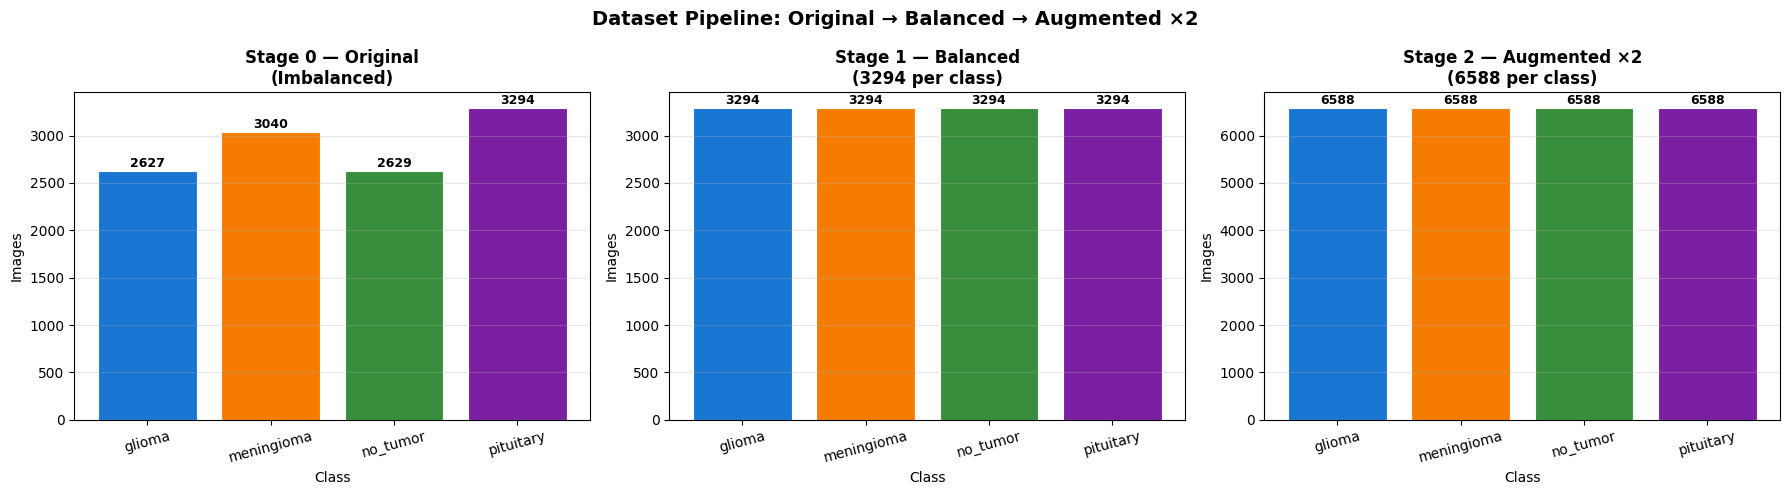

✅ Chart saved!


In [ ]:
import os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1976D2', '#F57C00', '#388E3C', '#7B1FA2']

stages = [
    (original_counts,  'Stage 0 — Original\n(Imbalanced)'),
    (balanced_counts,  f'Stage 1 — Balanced\n({balanced_target} per class)'),
    (augmented_counts, f'Stage 2 — Augmented ×2\n({balanced_target*2} per class)'),
]

for ax, (counts, title) in zip(axes, stages):
    classes = list(counts.keys())
    values  = list(counts.values())
    bars = ax.bar(classes, values, color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Dataset Pipeline: Original → Balanced → Augmented ×2',
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Corrected path for saving the figure
save_path = '/content/drive/MyDrive/dataset_pipeline_stages.png'

# Ensure the directory exists
save_dir = os.path.dirname(save_path)
os.makedirs(save_dir, exist_ok=True)

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## Step 12 — Preview: Original vs Augmented Twins
Shows the original image and its augmented copy side by side for each class.

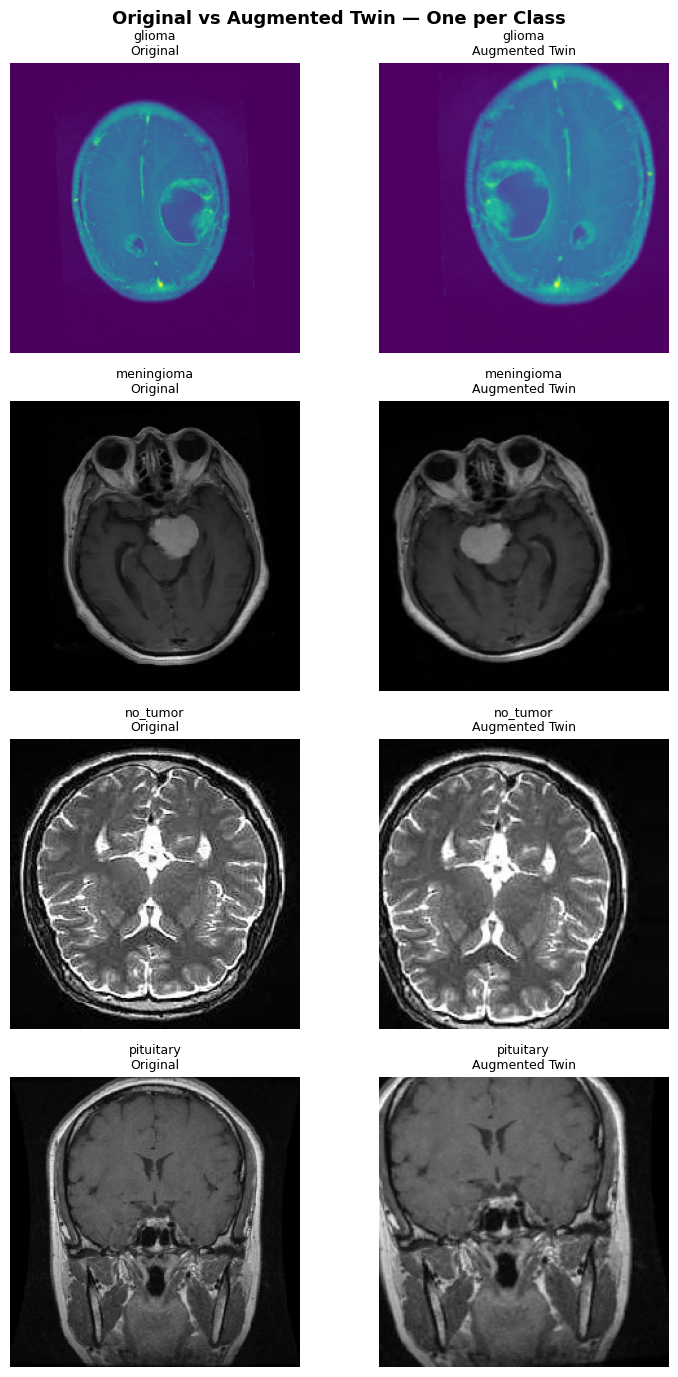

✅ Preview saved!


In [ ]:
import os

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, 14))

for row, cls in enumerate(sorted(os.listdir(augmented_dir))):
    cls_dir = os.path.join(augmented_dir, cls)
    all_files = os.listdir(cls_dir)

    # Find one original and its augmented twin
    orig_files = [f for f in all_files if f.startswith('orig_')]
    sample_orig = orig_files[0]
    sample_name = sample_orig[len('orig_'):]
    sample_aug  = f'aug_{sample_name}'

    orig_img = load_img(os.path.join(cls_dir, sample_orig), target_size=IMG_SIZE)
    aug_img  = load_img(os.path.join(cls_dir, sample_aug),  target_size=IMG_SIZE)

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f'{cls}\nOriginal', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(aug_img)
    axes[row, 1].set_title(f'{cls}\nAugmented Twin', fontsize=9)
    axes[row, 1].axis('off')

plt.suptitle('Original vs Augmented Twin — One per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()

# Corrected path for saving the figure
save_path = '/content/drive/MyDrive/original_vs_augmented.png'

# Ensure the directory exists
save_dir = os.path.dirname(save_path)
os.makedirs(save_dir, exist_ok=True)

plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Preview saved!')

## Step 13 — Create Data Generators from Final Augmented Dataset

> Since images are **already augmented on disk**, the training generator uses
> **only normalization** (no on-the-fly augmentation needed).
> This avoids double-augmenting the data.

In [ ]:
# ── Training: normalization only (augmentation already on disk) ───
train_datagen = ImageDataGenerator(rescale=1./255)

# ── Validation & Test: normalization only ─────────────────────────
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    augmented_dir,           # ← final 2x augmented directory
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False            # MUST be False for correct label alignment
)

print('\n✅ Data generators ready!')
print(f'  Train batches : {len(train_generator)}')
print(f'  Val   batches : {len(val_generator)}')
print(f'  Test  batches : {len(test_generator)}')
print(f'  Class indices : {train_generator.class_indices}')

Found 26352 images belonging to 4 classes.
Found 1586 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.

✅ Data generators ready!
  Train batches : 412
  Val   batches : 25
  Test  batches : 25
  Class indices : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


## Step 14 — Compute Class Weights

In [ ]:
labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights_array))

print('📊 Class Weights (should all be ~1.0 since dataset is balanced):')
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
for idx, weight in class_weight_dict.items():
    bar = '█' * int(weight * 20)
    print(f'  {idx_to_class[idx]:15s}: {weight:.4f}  {bar}')

print('\n✅ class_weight_dict ready for model.fit()')

📊 Class Weights (should all be ~1.0 since dataset is balanced):
  glioma         : 1.0000  ████████████████████
  meningioma     : 1.0000  ████████████████████
  no_tumor       : 1.0000  ████████████████████
  pituitary      : 1.0000  ████████████████████

✅ class_weight_dict ready for model.fit()


## Step 15 — Final Dataset Summary

In [ ]:
print('=' * 60)
print('📋 FINAL DATASET SUMMARY')
print('=' * 60)
print(f'  {"Stage":<25} {"Per Class":>10} {"Total":>10}')
print('-' * 60)
print(f'  {"Original (imbalanced)":<25}',
      f'{"varies":>10}',
      f'{sum(original_counts.values()):>10}')
print(f'  {"Stage 1: Balanced":<25}',
      f'{balanced_target:>10}',
      f'{sum(balanced_counts.values()):>10}')
print(f'  {"Stage 2: Augmented x2":<25}',
      f'{balanced_target*2:>10}',
      f'{sum(augmented_counts.values()):>10}')
print('-' * 60)
print(f'  Val  images  : {sum(count_images(valid_dir).values())}')
print(f'  Test images  : {sum(count_images(test_dir).values())}')
print('=' * 60)
print()
print('✅ Pipeline complete! Use these variables in your model:')
print('   train_generator   → feed into model.fit()')
print('   val_generator     → validation_data in model.fit()')
print('   test_generator    → model.evaluate() and model.predict()')
print('   class_weight_dict → class_weight in model.fit()')

📋 FINAL DATASET SUMMARY
  Stage                      Per Class      Total
------------------------------------------------------------
  Original (imbalanced)         varies      11590
  Stage 1: Balanced               3294      13176
  Stage 2: Augmented x2           6588      26352
------------------------------------------------------------
  Val  images  : 1586
  Test images  : 1584

✅ Pipeline complete! Use these variables in your model:
   train_generator   → feed into model.fit()
   val_generator     → validation_data in model.fit()
   test_generator    → model.evaluate() and model.predict()
   class_weight_dict → class_weight in model.fit()
